# TP2 - MLP pour la classification et la régression

In [1]:
# Imports et fonctions utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()
    
def show_errors_img(X, Y_pred, Y_true, shape=(28,28), dpi=100):  
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    n = min(len(X), len(Y_pred), len(Y_true), 30) # 30 erreurs au maximum
    X, Y_pred, Y_true = X[:n], Y_pred[:n], Y_true[:n]
    nl = n // 10
    if n%10!=0: nl += 1 
    
    for i in range(n):
        plt.subplot(nl,10,i+1)
        x, yp, yt = X[i], Y_pred[i], Y_true[i]
        plt.imshow(x.reshape(shape), cmap='gray')
        plt.axis('off')
        plt.title(str(yp)+' ('+str(yt)+')')
    plt.plot()
    
def show_model_errors(model, X, y):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)

    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    show_errors_img(X[errors], y_pred[errors], y[errors])

## 1/ MLP sur MNIST

1/ Adapter le modèle issu du TP1 de manière à pouvoir comparer observer les performances d'autres architectures de MLP, en particulier des MLP à plusieurs couches cachées (par exemple, 1 ou 2 couches cachées de 64 neurones avec activation RelU).

Vous produirez un graphique montrant l'évolution des précision d'entrainement et de tests au fur-et-à-mesure des itérations et un graphique montrant l'évolution des loss. 

Si l'on fait tourner l'entrainement suffisemment longtemps (100 à 200 itérations), quel phénomène est mis en évidence ?





In [25]:
from keras.datasets import mnist
(X_train, y_train), (X_val, y_val) = mnist.load_data()
# - On normalise en divisant par 255 (valeur maximale d'un pixel)
X_train = X_train / 255
X_val = X_val / 255

acc = {}
loss = {}

In [33]:
NOM = "MLP1x64"

model = keras.models.Sequential()
model.add(keras.layers.Input(X_train.shape[1:]))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()


taille_batch = 64
nb_iterations = 10

s = model.fit(X_train, y_train, batch_size = taille_batch, epochs = nb_iterations, verbose = 1, validation_data= (X_val, y_val))

acc[NOM+"_train"] = s.history['accuracy']
acc[NOM+"_val"] = s.history['val_accuracy']

loss[NOM+"_train"] = s.history['val_loss']
loss[NOM+"_val"] = s.history['loss']

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7711 - loss: 0.9181 - val_accuracy: 0.8795 - val_loss: 0.4704
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8865 - loss: 0.4243 - val_accuracy: 0.9029 - val_loss: 0.3583
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9025 - loss: 0.3541 - val_accuracy: 0.9120 - val_loss: 0.3180
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9103 - loss: 0.3203 - val_accuracy: 0.9170 - val_loss: 0.2940
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9164 - loss: 0.2981 - val_accuracy: 0.9223 - val_loss: 0.2758
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9207 - loss: 0.2811 - val_accuracy: 0.9267 - val_loss: 0.2617
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9249 - loss: 0.2675 - val_accuracy: 0.9288 - val_loss: 0.2510
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9277 - loss: 0.2556 - val_accuracy: 0.

<Axes: >

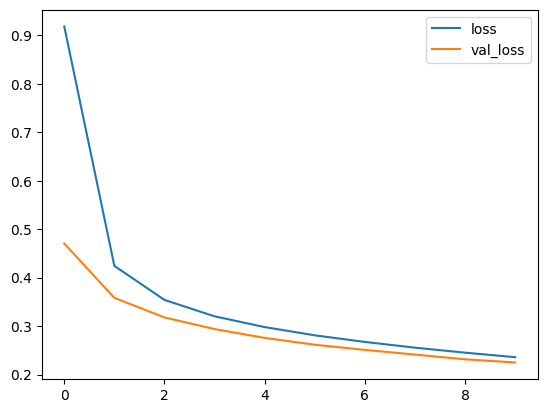

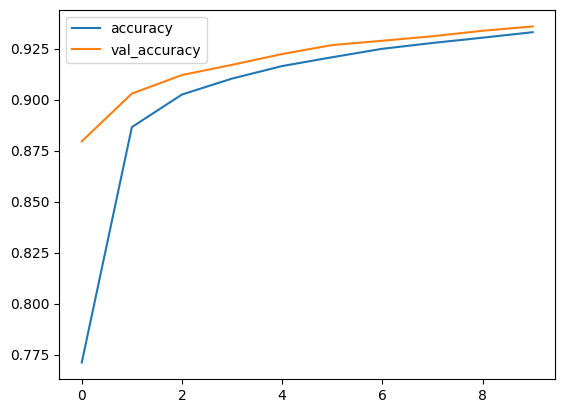

In [34]:
pd.DataFrame(s.history, columns=['loss', 'val_loss']).plot()
pd.DataFrame(s.history, columns=['accuracy', 'val_accuracy']).plot()

<Axes: title={'center': "Evolution de la loss au cours de l'entrainement"}>

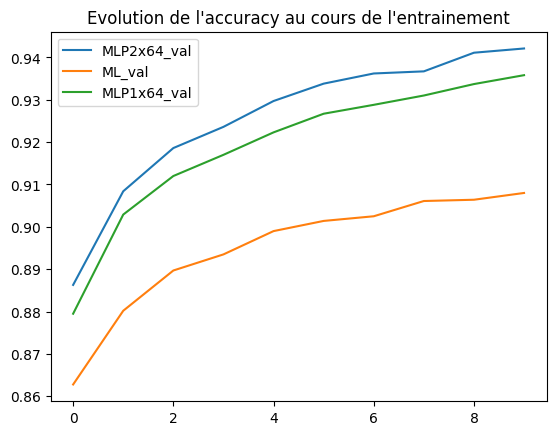

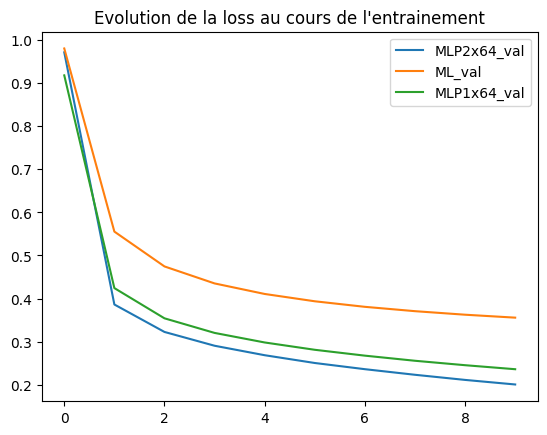

In [ ]:
pd.DataFrame(acc, columns= [x for x in acc if "val" in x]).plot(title="Evolution de l'accuracy au cours de l'entrainement") 
pd.DataFrame(loss, columns= [x for x in acc if "val" in x]).plot( title="Evolution de la loss au cours de l'entrainement")



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


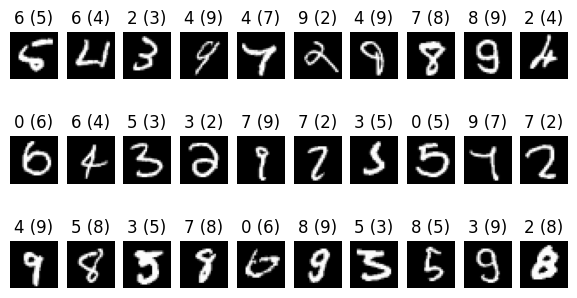

In [28]:
show_model_errors(model, X_val, y_val)



2/ Modifier le programme de manière à permettre la comparaison des performances de plusieurs modèles dans un même graphique (un graphique par type de mesure)
Pour cela, il faudra : 
- adapter le programme de manière à pouvoir stocker les résultats de chaque modèle dans un dictionnaire afin de pouvoir facilement les projeter sur un même graphique
- adapter le programme pour que si l'on relance un entrainement sur un modèle déjà entraîné, ses résulats viennent s'ajouter aux précédents au lieu de les remplacer


## 2/ Régression sur les données "California Housing"

Entrainer un MLP pour prédire le prix de maisons en Californie (prix médians selon le district).
Keras permet de récupérer les données dans le sous-module `keras.datasets.california_housing`.


## 3/ Classification sur les données "Fashion MNIST"

Refaire l'exercice 1 avec les données Fashion MNIST.
Keras permet de récupérer les données dans le sous-module `keras.datasets.fashion_mnist`.


---